In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
np.random.seed(42)

## Данные

In [3]:
# Количество наблюдений в синтетическом наборе данных
# В нашем случае каждое наблюдение можно интерпретировать как отдельный район города
n = 100

# Генерируем количество автомобилей в районе.
# Значения случайно выбираются из диапазона от 100 до 999.
# Предполагаем, что чем больше автомобилей, тем выше уровень загрязнения.
cars = np.random.randint(100, 1000, size=n)

# Генерируем условный показатель промышленного производства.
# Значения случайно выбираются из диапазона от 50 до 499.
# Предполагаем, что промышленность также увеличивает уровень загрязнения.
industry = np.random.randint(50, 500, size=n)

# Генерируем количество деревьев или условный показатель озеленения района.
# Значения случайно выбираются из диапазона от 10 до 99.
# Предполагаем, что большее количество деревьев снижает уровень загрязнения.
trees = np.random.randint(10, 100, size=n)

# Формируем целевую переменную — уровень загрязнения.
# Используется линейная модель:
#
# pollution = 100 + 0.5 * cars + 0.3 * industry - 1.5 * trees + noise
#
# Здесь:
# 100 — свободный член модели;
# 0.5 — вклад количества автомобилей;
# 0.3 — вклад промышленного производства;
# -1.5 — вклад деревьев, снижающий загрязнение;
# np.random.normal(0, 10, size=n) — случайный шум, имитирующий влияние неучтённых факторов.
pollution = (
    100
    + 0.5 * cars
    + 0.3 * industry
    - 1.5 * trees
    + np.random.normal(0, 10, size=n)
)

# Собираем сгенерированные данные в таблицу pandas DataFrame.
# Каждая строка соответствует одному наблюдению,
# каждый столбец — отдельной переменной.
df = pd.DataFrame({
    'pollution': pollution,
    'cars': cars,
    'industry': industry,
    'trees': trees
})

# Формируем матрицу признаков X.
# В неё входят независимые переменные, по которым мы будем предсказывать загрязнение.
X = df[['cars', 'industry', 'trees']]

# Формируем целевую переменную y.
# Это зависимая переменная, которую должна предсказывать модель регрессии.
y = df['pollution']

## Метод наименьших квадратов

In [5]:
# Используем библиотеку statsmodels.
# Она удобна для классического регрессионного анализа,
# так как позволяет получить подробную статистическую сводку по модели.


# В модели линейной регрессии обычно есть свободный член:
#
# pollution = b0 + b1 * cars + b2 * industry + b3 * trees + error
#
# В statsmodels свободный член не добавляется автоматически,
# поэтому его нужно явно добавить к матрице признаков X.
X_with_const = sm.add_constant(X)

# Создаём модель линейной регрессии.
# OLS означает Ordinary Least Squares, то есть обычный метод наименьших квадратов.
#
# Первый аргумент — зависимая переменная y.
# Второй аргумент — матрица независимых переменных X_with_const.
model = sm.OLS(y, X_with_const)

# Оцениваем параметры модели методом наименьших квадратов.
# Метод fit() подбирает такие коэффициенты,
# при которых сумма квадратов ошибок модели минимальна.
results = model.fit()

# Выводим подробную статистическую сводку по модели.
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              pollution   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     7312.
Date:                Sun, 03 May 2026   Prob (F-statistic):          3.77e-113
Time:                        16:06:06   Log-Likelihood:                -369.75
No. Observations:                 100   AIC:                             747.5
Df Residuals:                      96   BIC:                             757.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.5483      3.920     26.926      0.0

In [6]:
# Рассчитаем базовые характеристики качества модели и точности оценок

# Количество наблюдений
n = X_with_const.shape[0]

# Количество оцениваемых параметров модели:
# свободный член + коэффициенты при признаках
p = X_with_const.shape[1]

# Получаем фактические значения целевой переменной
y_true = y

# Получаем предсказанные моделью значения
y_pred = results.fittedvalues

# Остатки модели:
# e_i = y_i - y_hat_i
residuals = y_true - y_pred

# Сумма квадратов остатков:
# RSS = sum((y_i - y_hat_i)^2)
RSS = np.sum(residuals ** 2)

# Общая сумма квадратов:
# TSS = sum((y_i - y_mean)^2)
TSS = np.sum((y_true - np.mean(y_true)) ** 2)

# Оценка остаточной дисперсии:
# sigma_hat^2 = RSS / (n - p)
#
# Делим не на n, а на n - p, потому что p параметров модели
# были оценены по этим же данным.
residual_variance = RSS / (n - p)

# Корень из остаточной дисперсии:
# sigma_hat = sqrt(sigma_hat^2)
#
# Эту величину можно интерпретировать как типичный масштаб ошибки модели
# в единицах измерения целевой переменной.
residual_std = np.sqrt(residual_variance)

# Коэффициент детерминации:
# R^2 = 1 - RSS / TSS
#
# Показывает, какая доля вариации зависимой переменной
# объясняется построенной регрессионной моделью.
r_squared = 1 - RSS / TSS

# Скорректированный коэффициент детерминации:
# Adjusted R^2 = 1 - (RSS / (n - p)) / (TSS / (n - 1))
#
# В отличие от обычного R^2, учитывает количество параметров в модели.
adjusted_r_squared = 1 - (RSS / (n - p)) / (TSS / (n - 1))

# Стандартные ошибки оценок коэффициентов.
#
# Теоретически ковариационная матрица оценок имеет вид:
# Var(beta_hat) = sigma_hat^2 * (X'X)^(-1)
#
# Стандартные ошибки — это корни из диагональных элементов этой матрицы.
X_matrix = X_with_const.values
cov_beta = residual_variance * np.linalg.inv(X_matrix.T @ X_matrix)
standard_errors = np.sqrt(np.diag(cov_beta))

# Соберём оценки коэффициентов и их стандартные ошибки в отдельную таблицу
coef_table = pd.DataFrame({
    "Параметр": X_with_const.columns,
    "Оценка коэффициента": results.params.values,
    "Стандартная ошибка": standard_errors
})

# Выведем основные показатели
print("RSS:", RSS)
print("Остаточная дисперсия:", residual_variance)
print("Корень из остаточной дисперсии:", residual_std)
print("R^2:", r_squared)
print("Скорректированный R^2:", adjusted_r_squared)

# Выведем таблицу коэффициентов и стандартных ошибок
coef_table

RSS: 9530.682199591598
Остаточная дисперсия: 99.27793957907915
Корень из остаточной дисперсии: 9.963831571191834
R^2: 0.9956429845168425
Скорректированный R^2: 0.9955068277829938


,Параметр,Оценка коэффициента,Стандартная ошибка
0,const,105.548253,3.919875
1,cars,0.495904,0.003820
2,industry,0.292385,0.007958
3,trees,-1.532879,0.036846


In [9]:
print("Остаточная дисперсия из statsmodels:", results.mse_resid)
print("Корень из остаточной дисперсии из statsmodels:", np.sqrt(results.mse_resid))
print("R^2 из statsmodels:", results.rsquared)
print("Скорректированный R^2 из statsmodels:", results.rsquared_adj)

results.bse

Остаточная дисперсия из statsmodels: 99.27793957907915
Корень из остаточной дисперсии из statsmodels: 9.963831571191834
R^2 из statsmodels: 0.9956429845168425
Скорректированный R^2 из statsmodels: 0.9955068277829938


,0
const,3.919875
cars,0.003820
industry,0.007958
trees,0.036846


## Проверка несмещенности модели

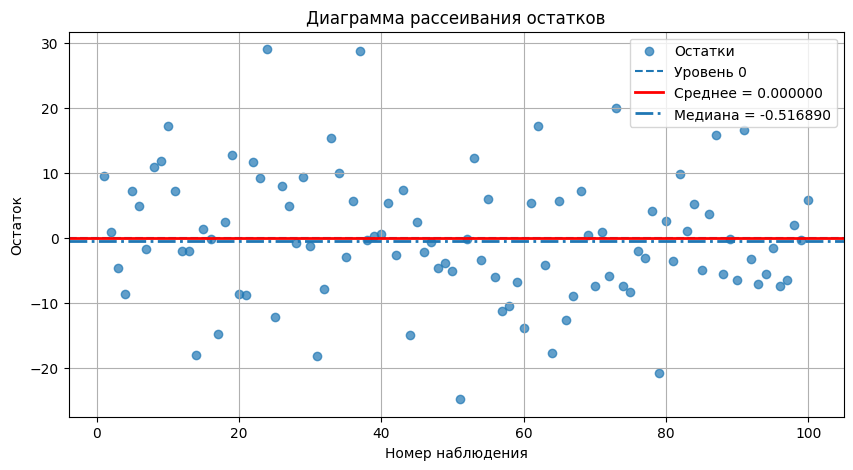

Среднее значение остатков: 0.0000000000
Медианное значение остатков: -0.5168902419
t-статистика: 0.0000000000
p-value: 1.0000000000
На уровне значимости 0.05 нет оснований отвергать H0: среднее остатков статистически не отличается от 0.


In [8]:
# Проверка предпосылки M(e) = 0:
# 1) визуализируем остатки;
# 2) проведём горизонтальные линии по среднему и медиане остатков;
# 3) проверим гипотезу H0: математическое ожидание остатков равно 0.

residuals = results.resid

# Номер наблюдения для оси X
obs_index = np.arange(1, len(residuals) + 1)

# Среднее и медиана остатков
res_mean = np.mean(residuals)
res_median = np.median(residuals)

# Строим диаграмму рассеивания остатков
plt.figure(figsize=(10, 5))
plt.scatter(obs_index, residuals, alpha=0.7, label='Остатки')

# Горизонтальная линия на уровне 0
plt.axhline(0, linestyle='--', linewidth=1.5, label='Уровень 0')

# Горизонтальная линия по среднему значению остатков
plt.axhline(res_mean, linestyle='-', linewidth=2, label=f'Среднее = {res_mean:.6f}', color = 'red')

# Горизонтальная линия по медианному значению остатков
plt.axhline(res_median, linestyle='-.', linewidth=2, label=f'Медиана = {res_median:.6f}')

plt.xlabel('Номер наблюдения')
plt.ylabel('Остаток')
plt.title('Диаграмма рассеивания остатков')
plt.legend()
plt.grid(True)
plt.show()

# Проверка гипотезы:
# H0: математическое ожидание остатков равно 0
# H1: математическое ожидание остатков не равно 0
#
# Используем одновыборочный t-критерий Стьюдента
t_stat, p_value = stats.ttest_1samp(residuals, popmean=0)

alpha = 0.05

print(f"Среднее значение остатков: {res_mean:.10f}")
print(f"Медианное значение остатков: {res_median:.10f}")
print(f"t-статистика: {t_stat:.10f}")
print(f"p-value: {p_value:.10f}")

if p_value < alpha:
    print("На уровне значимости 0.05 гипотеза H0 отвергается: среднее остатков статистически значимо отличается от 0.")
else:
    print("На уровне значимости 0.05 нет оснований отвергать H0: среднее остатков статистически не отличается от 0.")

## Проверка гомоскедастичности

Одна из предпосылок классической линейной регрессии состоит в том, что дисперсия случайной ошибки постоянна при разных значениях объясняющих переменных:

$$
\operatorname{Var}(\varepsilon_i \mid X) = \sigma^2
$$

Это свойство называется гомоскедастичностью.

Если дисперсия ошибки зависит от признаков или от уровня предсказанного значения, возникает гетероскедастичность. В этом случае оценки коэффициентов МНК остаются несмещёнными при выполнении остальных предпосылок, но стандартные ошибки, t-статистики, p-value и доверительные интервалы могут стать некорректными.

Сначала построим график остатков против предсказанных значений. Если гомоскедастичность выполняется, остатки должны быть распределены вокруг нуля примерно с одинаковым разбросом на всём диапазоне предсказаний.

Затем применим два формальных теста:

**Тест Бройша — Пагана**

Нулевая гипотеза:

$$
H_0: \operatorname{Var}(\varepsilon_i \mid X) = \sigma^2
$$

Альтернативная гипотеза:

$$
H_1: \operatorname{Var}(\varepsilon_i \mid X) \neq \sigma^2
$$

H0: дисперсия ошибок постоянна, то есть имеет место гомоскедастичность.

H1: дисперсия ошибок зависит от объясняющих переменных.

Механика теста:
- сначала оценивается исходная регрессионная модель;
- затем берутся квадраты остатков;
- квадраты остатков регрессируются на объясняющие переменные;
- если объясняющие переменные статистически значимо объясняют квадраты остатков, есть основания говорить о гетероскедастичности.

**Тест Уайта**

Нулевая гипотеза:

$$
H_0: \operatorname{Var}(\varepsilon_i \mid X) = \sigma^2
$$

Альтернативная гипотеза:

$$
H_1: \operatorname{Var}(\varepsilon_i \mid X) = f(X)
$$


H0: дисперсия ошибок постоянна.

H1: дисперсия ошибок зависит от объясняющих переменных, их квадратов и попарных взаимодействий.

Механика теста:
- тест Уайта также использует вспомогательную регрессию квадратов остатков;
- но в отличие от теста Бройша — Пагана он допускает более сложную зависимость дисперсии от факторов;
- поэтому тест Уайта является более общим, но может быть менее устойчивым на малых выборках.

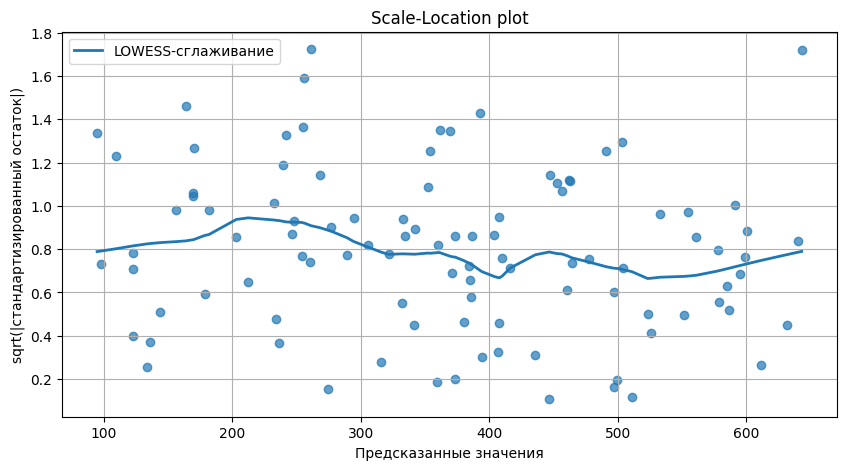

In [16]:
# Предсказанные значения модели
y_pred = results.fittedvalues

# Сырые остатки модели
residuals = results.resid

# Получаем стандартизированные остатки.
# Стандартизированный остаток показывает ошибку модели
# в единицах её стандартного отклонения.
influence = results.get_influence()
standardized_residuals = influence.resid_studentized_internal

# Для Scale-Location plot обычно используют:
# sqrt(abs(standardized residuals))
scale_location_values = np.sqrt(np.abs(standardized_residuals))

plt.figure(figsize=(10, 5))

plt.scatter(y_pred, scale_location_values, alpha=0.7)

# LOWESS-сглаживание для выявления тренда в масштабе остатков
lowess_scale = lowess(scale_location_values, y_pred, frac=0.3)
plt.plot(lowess_scale[:, 0], lowess_scale[:, 1], linewidth=2, label='LOWESS-сглаживание')

plt.xlabel('Предсказанные значения')
plt.ylabel('sqrt(|стандартизированный остаток|)')
plt.title('Scale-Location plot')
plt.legend()
plt.grid(True)
plt.show()

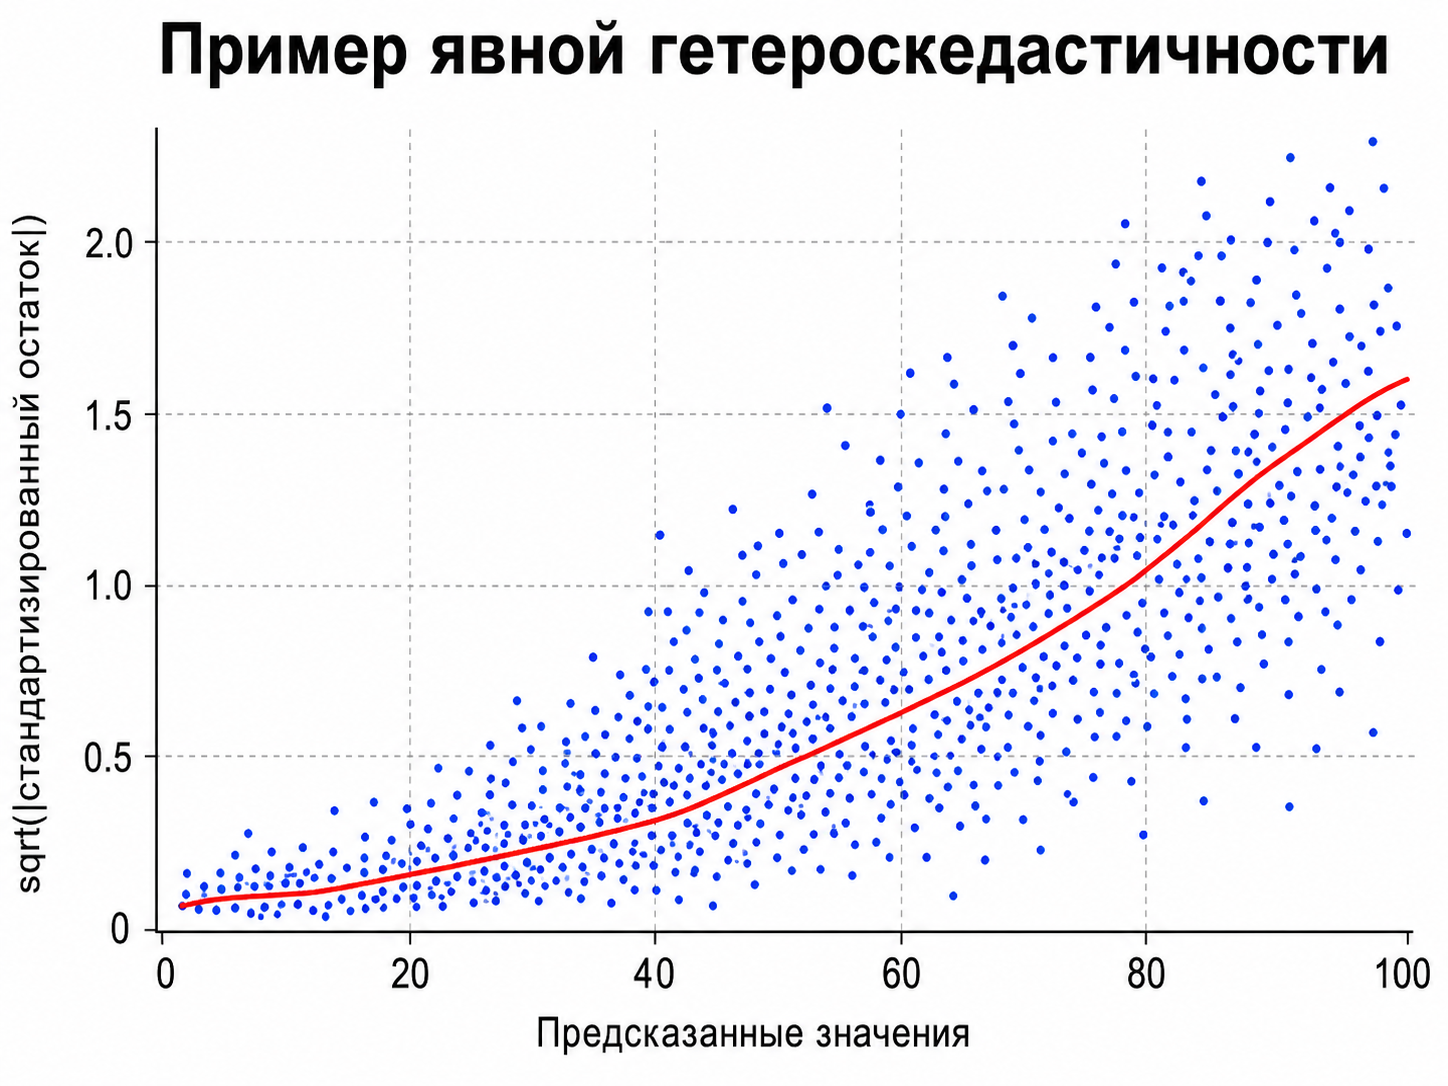

In [13]:
# Формальные тесты на гомоскедастичность

alpha = 0.05

# ------------------------------------------------------------
# 1. Тест Бройша — Пагана
# ------------------------------------------------------------
#
# H0: дисперсия ошибок постоянна, то есть наблюдается гомоскедастичность.
# H1: дисперсия ошибок зависит от объясняющих переменных,
#     то есть наблюдается гетероскедастичность.
#
# Механика теста:
# - берутся остатки исходной модели;
# - вычисляются квадраты остатков;
# - строится вспомогательная регрессия квадратов остатков на признаки;
# - если признаки значимо объясняют квадраты остатков,
#   то есть основания подозревать гетероскедастичность.
#
# Функция het_breuschpagan возвращает:
# LM-статистику, p-value для LM-статистики,
# F-статистику и p-value для F-статистики.

bp_test = het_breuschpagan(residuals, X_with_const)

bp_lm_stat = bp_test[0]
bp_lm_pvalue = bp_test[1]
bp_f_stat = bp_test[2]
bp_f_pvalue = bp_test[3]


# ------------------------------------------------------------
# 2. Тест Уайта
# ------------------------------------------------------------
#
# H0: дисперсия ошибок постоянна, то есть наблюдается гомоскедастичность.
# H1: дисперсия ошибок зависит от признаков, их квадратов
#     и попарных взаимодействий.
#
# Механика теста:
# - как и в тесте Бройша — Пагана, анализируются квадраты остатков;
# - но во вспомогательную регрессию включаются не только исходные признаки,
#   но также их квадраты и взаимодействия;
# - поэтому тест Уайта способен обнаружить более сложные формы
#   гетероскедастичности.
#
# Функция het_white возвращает:
# LM-статистику, p-value для LM-статистики,
# F-статистику и p-value для F-статистики.

white_test = het_white(residuals, X_with_const)

white_lm_stat = white_test[0]
white_lm_pvalue = white_test[1]
white_f_stat = white_test[2]
white_f_pvalue = white_test[3]


# Соберём результаты тестов в таблицу
homoscedasticity_tests = pd.DataFrame({
    "Тест": [
        "Бройша — Пагана",
        "Уайта"
    ],
    "H0": [
        "Дисперсия ошибок постоянна",
        "Дисперсия ошибок постоянна"
    ],
    "LM-статистика": [
        bp_lm_stat,
        white_lm_stat
    ],
    "p-value LM": [
        bp_lm_pvalue,
        white_lm_pvalue
    ],
    "F-статистика": [
        bp_f_stat,
        white_f_stat
    ],
    "p-value F": [
        bp_f_pvalue,
        white_f_pvalue
    ]
})

homoscedasticity_tests

,Тест,H0,LM-статистика,p-value LM,F-статистика,p-value F
0,Бройша — Пагана,Дисперсия ошибок постоянна,1.239192,0.743621,0.401517,0.752223
1,Уайта,Дисперсия ошибок постоянна,7.311916,0.604680,0.788873,0.627209


## Проверка отсутствия мультиколлинеарности

Ещё одна важная предпосылка классической линейной регрессии состоит в том, что между объясняющими переменными не должно быть точной или сильной линейной зависимости.

Если признаки сильно коррелируют друг с другом, возникает мультиколлинеарность. В этом случае модель может сохранять высокое качество предсказания, но отдельные коэффициенты становятся нестабильными: их стандартные ошибки растут, доверительные интервалы расширяются, а t-критерии могут становиться незначимыми.

Для диагностики мультиколлинеарности используем показатель VIF — Variance Inflation Factor.

Для каждого признака $X_j$ строится вспомогательная регрессия, в которой этот признак объясняется через остальные признаки. Затем рассчитывается:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

где $R_j^2$ — коэффициент детерминации вспомогательной регрессии признака $X_j$ на остальные признаки.

Интерпретация:

- $VIF = 1$ — признак не имеет линейной связи с остальными признаками;
- $1 < VIF < 5$ — умеренная связь, обычно не считается серьёзной проблемой;
- $VIF > 5$ — возможная проблема мультиколлинеарности;
- $VIF > 10$ — сильная мультиколлинеарность.

В нашем синтетическом примере признаки генерировались независимо, поэтому ожидается, что значения VIF будут близки к 1.

In [17]:
# Проверка мультиколлинеарности с помощью VIF

# Для расчёта VIF добавляем константу.
# Это нужно для корректного построения вспомогательных регрессий.
X_vif = sm.add_constant(X)

# Рассчитываем VIF для каждого признака.
# Саму константу в итоговую таблицу не включаем,
# потому что нас интересует мультиколлинеарность между объясняющими переменными.
vif_data = []

for i, column in enumerate(X_vif.columns):
    if column == "const":
        continue

    vif_value = variance_inflation_factor(X_vif.values, i)

    vif_data.append({
        "Признак": column,
        "VIF": vif_value,
        "Tolerance": 1 / vif_value
    })

vif_table = pd.DataFrame(vif_data)

vif_table

,Признак,VIF,Tolerance
0,cars,1.016878,0.983402
1,industry,1.011663,0.988472
2,trees,1.028186,0.972587


## Проверка независимости ошибок

Ещё одна предпосылка классической линейной регрессии состоит в том, что случайные ошибки разных наблюдений не должны быть связаны друг с другом.

Формально это можно записать так:

$$
\operatorname{Cov}(\varepsilon_i, \varepsilon_j \mid X) = 0, \quad i \neq j
$$

Если ошибки зависимы, например наблюдается автокорреляция, то оценки коэффициентов МНК могут оставаться несмещёнными при выполнении остальных предпосылок, но стандартные ошибки, t-статистики, p-value и доверительные интервалы могут быть некорректными.

Для проверки независимости ошибок используем:

1. График остатков в порядке наблюдений.

Если ошибки независимы, остатки должны хаотично колебаться вокруг нуля без видимого тренда, циклов или длинных серий положительных/отрицательных значений.

2. Статистику Дарбина — Уотсона.

Она проверяет наличие автокорреляции первого порядка между соседними остатками.

Значение статистики находится примерно в диапазоне от 0 до 4:

- значение около 2 означает отсутствие автокорреляции;
- значение меньше 2 указывает на положительную автокорреляцию;
- значение больше 2 указывает на отрицательную автокорреляцию.

3. Тест Льюнга — Бокса.

Нулевая гипотеза:

$$
H_0: \rho_1 = \rho_2 = \dots = \rho_k = 0
$$

То есть автокорреляции остатков до заданного лага отсутствуют.

Альтернативная гипотеза:

$$
H_1: \text{хотя бы одна автокорреляция отлична от нуля}
$$

Механика теста состоит в том, что он анализирует сразу несколько автокорреляций остатков и проверяет, можно ли считать их совместно равными нулю.

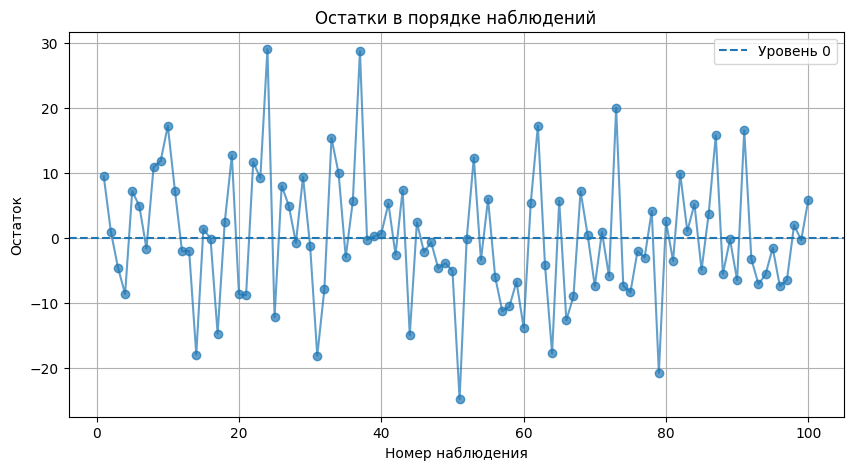

In [18]:
# Проверка независимости ошибок: график остатков по порядку наблюдений

# Остатки модели
residuals = results.resid

# Номера наблюдений
obs_index = np.arange(1, len(residuals) + 1)

plt.figure(figsize=(10, 5))

plt.plot(obs_index, residuals, marker='o', linestyle='-', alpha=0.7)

# Горизонтальная линия на уровне нуля
plt.axhline(0, linestyle='--', linewidth=1.5, label='Уровень 0')

plt.xlabel('Номер наблюдения')
plt.ylabel('Остаток')
plt.title('Остатки в порядке наблюдений')
plt.legend()
plt.grid(True)
plt.show()

<Figure size 800x500 with 0 Axes>

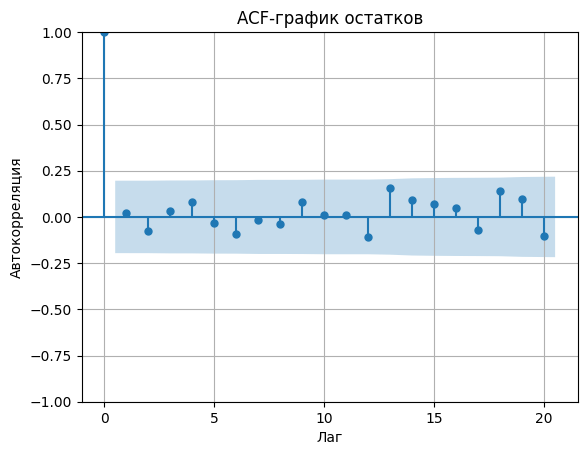

In [20]:
# График автокорреляционной функции остатков

plt.figure(figsize=(8, 5))

plot_acf(residuals, lags=20, alpha=0.05)

plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.title('ACF-график остатков')
plt.grid(True)
plt.show()

In [23]:
# Формальная проверка независимости ошибок
alpha = 0.05

# ------------------------------------------------------------
# 1. Статистика Дарбина — Уотсона
# ------------------------------------------------------------
#
# H0 в содержательном смысле:
# отсутствует автокорреляция остатков первого порядка.
#
# Если DW ≈ 2, автокорреляция первого порядка не выражена.
# Если DW < 2, возможна положительная автокорреляция.
# Если DW > 2, возможна отрицательная автокорреляция.

dw_stat = durbin_watson(residuals)

print(f"Статистика Дарбина — Уотсона: {dw_stat:.4f}")

if 1.5 <= dw_stat <= 2.5:
    print("Значение близко к 2: явных признаков автокорреляции первого порядка нет.")
elif dw_stat < 1.5:
    print("Значение заметно меньше 2: возможна положительная автокорреляция остатков.")
else:
    print("Значение заметно больше 2: возможна отрицательная автокорреляция остатков.")

Статистика Дарбина — Уотсона: 1.9442
Значение близко к 2: явных признаков автокорреляции первого порядка нет.


In [24]:
# ------------------------------------------------------------
# 2. Тест Льюнга — Бокса
# ------------------------------------------------------------
#
# H0: автокорреляции остатков до выбранного лага равны нулю.
# H1: хотя бы одна автокорреляция статистически значимо отличается от нуля.
#
# Проверим несколько лагов: 5, 10 и 15.

ljung_box_results = acorr_ljungbox(
    residuals,
    lags=[5, 10, 15],
    return_df=True
)

ljung_box_results

,lb_stat,lb_pvalue
5,1.534039,0.909109
10,3.362877,0.971550
15,9.271410,0.862904


In [25]:
# Интерпретация теста Льюнга — Бокса

for lag, row in ljung_box_results.iterrows():
    p_value = row["lb_pvalue"]

    if p_value < alpha:
        conclusion = (
            f"p-value = {p_value:.6f} < {alpha}. "
            "Гипотеза H0 отвергается: есть признаки автокорреляции остатков."
        )
    else:
        conclusion = (
            f"p-value = {p_value:.6f} >= {alpha}. "
            "Нет оснований отвергать H0: статистически значимой автокорреляции не обнаружено."
        )

    print(f"Лаг {lag}: {conclusion}")

Лаг 5: p-value = 0.909109 >= 0.05. Нет оснований отвергать H0: статистически значимой автокорреляции не обнаружено.
Лаг 10: p-value = 0.971550 >= 0.05. Нет оснований отвергать H0: статистически значимой автокорреляции не обнаружено.
Лаг 15: p-value = 0.862904 >= 0.05. Нет оснований отвергать H0: статистически значимой автокорреляции не обнаружено.
